# Notebook 04: Bernoulli Mixture Model (BMM)

In this notebook, we evaluate the **Bernoulli Distribution**. Unlike Gaussian and Laplacian models which work on continuous data, the Bernoulli distribution models discrete, binary events (0 or 1). 

Because of this, we cannot use our PCA-compressed data. PCA features are continuous floating-point numbers. Instead, we will use our fully uncompressed, binarized 784-dimensional dataset, where every single pixel acts as an independent coin flip (1 = white foreground, 0 = black background).


In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pickle
import seaborn as sns
from scipy.stats import mode
from tqdm import trange
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, accuracy_score, confusion_matrix

os.makedirs('images/bernoulli', exist_ok=True)

# Load the binarized, uncompressed 784-dimensional data
X_bin = np.load('data/X_binary.npy')

y = np.load('data/y_labels.npy')

print(f"Loaded X_bin shape: {X_bin.shape}")
print(f"Loaded labels shape: {y.shape}")
print(f"Min value: {X_bin.min()}, Max value: {X_bin.max()}") 

Loaded X_bin shape: (70000, 784)
Loaded labels shape: (70000,)
Min value: 0, Max value: 1


### Step 1: The Bernoulli Expectation-Maximization (EM) Algorithm

Since `scikit-learn` lacks a native Bernoulli Mixture clustering model, we built a custom class.


In [7]:
class BernoulliMixtureModel:
    def __init__(self, n_components=25, max_iter=50, tol=1e-4, verbose=True):
        self.K = n_components
        self.max_iter = max_iter
        self.tol = tol
        self.verbose = verbose

    def _e_step(self, X):
        # Clip probabilities to prevent log(0) errors
        log_mu = np.log(np.clip(self.mu, 1e-10, 1.0))
        log_1_minus_mu = np.log(np.clip(1 - self.mu, 1e-10, 1.0))
        
        # Fast vectorized log-probability calculation for Bernoulli
        # X is (N, D), log_mu is (K, D). Resulting log_pdf is (N, K)
        log_pdf = X @ log_mu.T + (1 - X) @ log_1_minus_mu.T
        log_resp = log_pdf + np.log(self.pi + 1e-10)

        # Log-sum-exp trick for numerical stability
        max_log_resp = np.max(log_resp, axis=1, keepdims=True)
        resp = np.exp(log_resp - max_log_resp)
        resp /= resp.sum(axis=1, keepdims=True)
        
        return resp, log_resp, max_log_resp

    def _m_step(self, X, resp):
        N, D = X.shape
        Nk = resp.sum(axis=0) + 1e-10
        self.pi = Nk / N
        
        # Update probabilities (mu) as the weighted average of the binary pixels
        self.mu = (resp.T @ X) / Nk[:, None]
        self.mu = np.clip(self.mu, 1e-10, 1 - 1e-10)

    def fit(self, X):
        N, D = X.shape
        
        # Initialize centers using K-Means (acting on binary data)
        km = KMeans(n_clusters=self.K, init='k-means++', n_init=5).fit(X)
        self.mu = np.clip(km.cluster_centers_, 1e-10, 1 - 1e-10)
        self.pi = np.ones(self.K) / self.K
        self.loss_history = []

        progress = trange(self.max_iter, desc="Training BMM", leave=True)
        for i in progress:
            resp, log_resp, max_log_resp = self._e_step(X)
            self._m_step(X, resp)

            if self.verbose:
                log_likelihood = np.sum(max_log_resp + np.log(np.sum(np.exp(log_resp - max_log_resp), axis=1, keepdims=True) + 1e-10))
                progress.set_description(f"Iter {i+1} | LogL: {log_likelihood:.2f}")
                
                if len(self.loss_history) > 0 and np.abs(log_likelihood - self.loss_history[-1]) < self.tol:
                    print(f"\nConverged at iteration {i+1}")
                    break
                self.loss_history.append(log_likelihood)

    def predict(self, X):
        resp, _, _ = self._e_step(X)
        return np.argmax(resp, axis=1)

    def sample(self, n_samples=10):
        samples = []
        component_ids = np.random.choice(self.K, size=n_samples, p=self.pi)
        for k in component_ids:
            # Draw each pixel from a Binomial/Bernoulli distribution using the learned probabilities
            x = np.random.binomial(n=1, p=self.mu[k])
            samples.append(x)
        return np.array(samples)

### Step 2: Training

We maintain $K=25$ for direct comparability with other Mixture Models.

Iter 50 | LogL: -10414139.47: 100%|██████████| 50/50 [00:49<00:00,  1.01it/s]


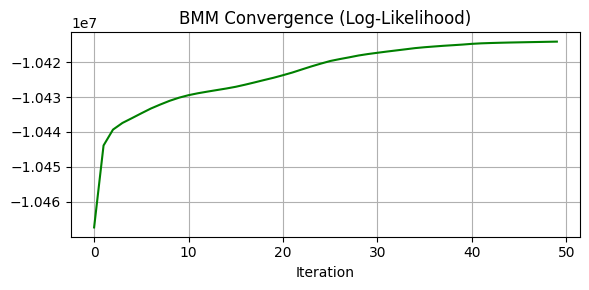

In [8]:
OPTIMAL_K = 25

bmm = BernoulliMixtureModel(n_components=OPTIMAL_K, max_iter=50, verbose=True)
bmm.fit(X_bin)

clusters = bmm.predict(X_bin)

# Plot Log-Likelihood convergence
plt.figure(figsize=(6, 3))
plt.plot(bmm.loss_history, color='green')
plt.title("BMM Convergence (Log-Likelihood)")
plt.xlabel("Iteration")
plt.grid(True)
plt.tight_layout()
plt.savefig('images/bernoulli/bernoulli_convergence.png', dpi=200, bbox_inches='tight')
plt.show()

### Step 3: Evaluation Metrics and Confusion Matrix

--- BMM Evaluation Metrics (K=25) ---
Mapped Accuracy (Purity): 75.86%
ARI: 0.3363
NMI: 0.5776



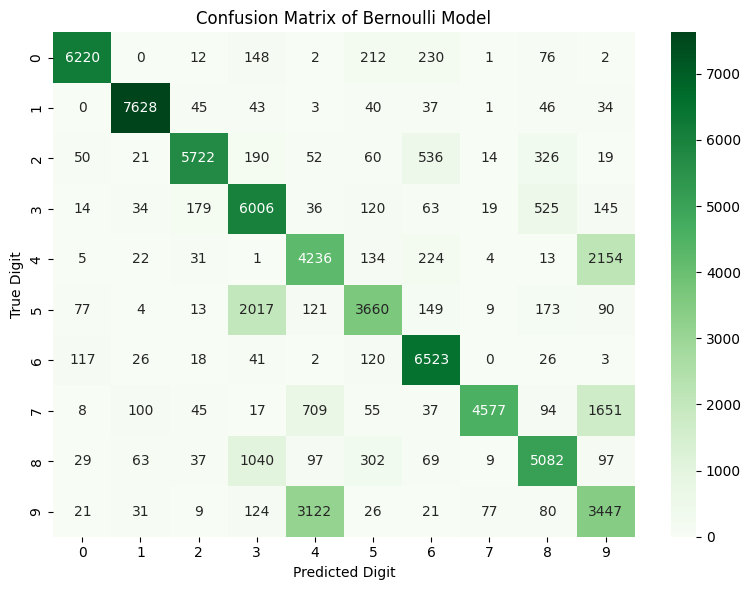

In [9]:
ari = adjusted_rand_score(y, clusters)
nmi = normalized_mutual_info_score(y, clusters)

def map_clusters_to_digits(y_true, y_pred, n_clusters):
    labels = np.zeros_like(y_pred)
    for cluster in range(n_clusters):
        mask = (y_pred == cluster)
        if np.any(mask):
            labels[mask] = mode(y_true[mask], keepdims=False).mode
    return labels

y_pred_mapped = map_clusters_to_digits(y, clusters, n_clusters=OPTIMAL_K)
acc = accuracy_score(y, y_pred_mapped)

print(f"--- BMM Evaluation Metrics (K={OPTIMAL_K}) ---")
print(f"Mapped Accuracy (Purity): {acc * 100:.2f}%")
print(f"ARI: {ari:.4f}")
print(f"NMI: {nmi:.4f}\n")

cm = confusion_matrix(y, y_pred_mapped, labels=range(10))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Digit')
plt.ylabel('True Digit')
plt.title('Confusion Matrix of Bernoulli Model')
plt.tight_layout()
plt.savefig('images/bernoulli/bernoulli_confusion.png', dpi=200, bbox_inches='tight')
plt.show()

# Save metrics for final comparison
bmm_metrics = {'Accuracy': acc, 'ARI': ari, 'NMI': nmi}
with open('data/bmm_metrics.pkl', 'wb') as f:
    pickle.dump(bmm_metrics, f)

### Step 4: Generative Sampling

Because the Bernoulli model deals in binary data, the mathematical output of our sampling function is a $28 \times 28$ grid of hard `0`s and `1`s. 

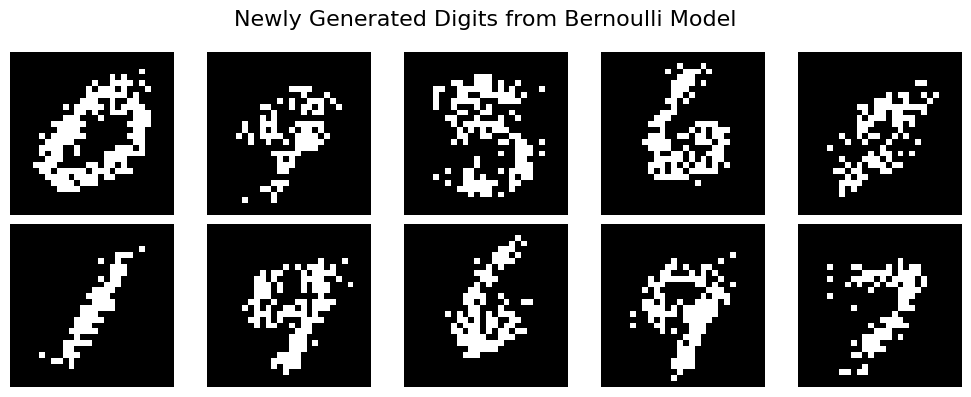

In [10]:
# Sample 10 new data points from the trained Bernoulli Mixture Model
new_bin_samples = bmm.sample(n_samples=10)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
fig.suptitle("Newly Generated Digits from Bernoulli Model", fontsize=16)

for i, ax in enumerate(axes.flatten()):
    # Reshape directly to 28x28 
    img = new_bin_samples[i].reshape(28, 28)
    # Use 'gray' colormap, but values are strictly 0 and 1
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.axis('off')

plt.tight_layout()
plt.savefig('images/bernoulli/bernoulli_samples.png', dpi=200, bbox_inches='tight')
plt.show()

# Save the 784-dimensional generated binary images
np.save('data/bmm_samples.npy', new_bin_samples)